#  🔮 Forecasting Strategies
---

## 🧭 Big picture

When forecasting **multiple future steps** (e.g., next 24 hours), you must choose *how* to generate that horizon. The strategy affects bias/variance, error propagation, runtime, and how your model uses seasonality and exogenous variables.

## 🔁 Recursive (Iterated)

**Idea:** Train **one** model for the next step (t→t+1). For t+2…H, feed each **prediction** back in as if it were real.

**Why you’d pick it**

* ✅ Simple and fast to maintain (one model)
* ✅ Strong when short horizon & strong autocorrelation
* ⚠️ **Error accumulation** across steps

**Use when**

* Short horizons (e.g., 1–6 steps)
* You retrain often and have rich lags + exogenous features

**Learn more:** Skforecast recursive forecaster → [https://skforecast.org/0.13.0/user_guides/autoregresive-forecaster](https://skforecast.org/0.13.0/user_guides/autoregresive-forecaster)

---

## 🎯 Direct

**Idea:** Train **H** separate models, one per horizon step (t→t+1, t→t+2, …, t→t+H). No prediction feedback.

**Why you’d pick it**

* ✅ No error propagation
* ✅ Each step can have its own features/dynamics
* ⚠️ Heavier training (H models)

**Use when**

* Medium/long horizons (e.g., 24–168 steps)
* Noisy series with heterogeneous step behavior

**Learn more:** Skforecast direct forecaster → [https://skforecast.org/0.13.0/user_guides/autoregresive-forecaster](https://skforecast.org/0.13.0/user_guides/autoregresive-forecaster)

---

## 🔁🎯 DirRec (Hybrid)

**Idea:** One model per step **and** later steps can use earlier **predictions** as features.

**Why you’d pick it**

* ✅ Reduces some error propagation vs pure recursive
* ✅ Keeps step-specific modeling
* ⚠️ More complex; still can propagate errors

**Use when**

* Moderate horizons with step interactions

**Learn more:** Conceptual variant discussed alongside recursive/direct in Skforecast guide → [https://skforecast.org/0.13.0/user_guides/autoregresive-forecaster](https://skforecast.org/0.13.0/user_guides/autoregresive-forecaster)

---

## 📦 MIMO (Multiple-Input Multiple-Output)

**Idea:** Train **one** model to output the **entire horizon vector** ([y_{t+1},\dots,y_{t+H}]) in a single shot.

**Why you’d pick it**

* ✅ Captures cross-step dependencies (daily “shape”)
* ✅ Single fit/predict for the whole horizon
* ⚠️ Needs models that support multi-output (or wrappers)

**Use when**

* Long horizons where shape coherence matters (e.g., 24-hour profile)
* You want consistent day-ahead curves

**Learn more:** Multi-output regression overview → [https://www.geeksforgeeks.org/multioutput-regression-in-machine-learning/](https://www.geeksforgeeks.org/multioutput-regression-in-machine-learning/)

---

## 🧪 Backtesting & evaluation (what actually matters)

* 🧱 **Temporal CV**: sliding or expanding windows; keep a clean **hold-out** block (e.g., last 2–4 weeks).
* 🕰️ **Per-horizon metrics**: MAE/RMSE for each step (h=1…H) + aggregate.
* 🧭 **Baselines first**: Seasonal naïve (e.g., yesterday’s same hour) should be your floor.
* 📈 **Features**: lags (1–48), seasonal lags (24, 168), hour/weekday, holidays, weather, and sin/cos seasonal cycles.
* 🧰 For an end-to-end example with energy features & honest splits:
  [https://cienciadedatos.net/documentos/py29-forecasting-electricity-power-demand-python.html](https://cienciadedatos.net/documentos/py29-forecasting-electricity-power-demand-python.html)

---

## 🥊 Strategy chooser (rules of thumb)

* **Short horizon (≤6)** → 🔁 **Recursive** (simple, strong with rich lags/exog).
* **Medium (6–48)** → 🎯 **Direct** (often more stable across steps).
* **Long (≥24–168) & shape matters** → 📦 **MIMO** (or 🔁🎯 DirRec).
* **Many similar series (meters/regions)** → use *global* ML with series ID (Skforecast plays nicely with this) → [https://skforecast.org/0.13.0/user_guides/autoregresive-forecaster](https://skforecast.org/0.13.0/user_guides/autoregresive-forecaster)

---

## ⚠️ Pitfalls & fixes

* 🚫 **Leakage**: never let future info into training folds; watch DST/resampling.
* 📉 **Error growth**: recursive can drift for long horizons → prefer direct/MIMO.
* 🔀 **Distribution shift** (you **control** loads with MPC): include policy/control features or simulate counterfactuals; evaluate on post-control distributions.
* 🌡️ **Exogenous alignment**: ensure weather/holiday features are aligned to forecast time, not actuals.

---

## 🧾  Comparison

| Strategy  | Models | Pros                          | Cons                        | Best for       |
| --------- | -----: | ----------------------------- | --------------------------- | -------------- |
| Recursive |      1 | Simple; uses auto-correlation | Error accumulation          | Short horizons |
| Direct    |      H | Stable per step; no feedback  | Heavier training            | 24–168 steps   |
| DirRec    |      H | Hybrid; mitigates some drift  | Complexity; still can drift | Moderate H     |
| MIMO      |      1 | Coherent multi-step shape     | Needs multi-output          | Long horizons  |

**Your quick move:** benchmark **Seasonal Naïve** → **Recursive** → **Direct** → **MIMO** on rolling backtests; pick the model with the best *median* per-horizon MAE and stable variance across folds.

---

### Sources 

* Ciencia de Datos (electricity demand tutorial):
  [https://cienciadedatos.net/documentos/py29-forecasting-electricity-power-demand-python.html](https://cienciadedatos.net/documentos/py29-forecasting-electricity-power-demand-python.html)
* Skforecast user guide (recursive/direct, diagrams & API):
  [https://skforecast.org/0.13.0/user_guides/autoregresive-forecaster](https://skforecast.org/0.13.0/user_guides/autoregresive-forecaster)
* GeeksforGeeks (multi-output regression explainer):
  [https://www.geeksforgeeks.org/multioutput-regression-in-machine-learning/](https://www.geeksforgeeks.org/multioutput-regression-in-machine-learning/)


# 📦 Loading libraries & 📁 reading data 

* **Why these libs?**

  * `pandas` for table ops and time indexing 🧮
  * `numpy` for numerics 🔢
  * `matplotlib` for quick visuals 📈
  * `statsmodels` for ACF/PACF and classical stats 🧪
  * `skforecast` + `xgboost` for autoregressive ML forecasters 🤖

* **Data expectations:** hourly timestamps + a numeric target (e.g., demand). Make sure timestamps are parsed as datetimes and the index is gap-free (or interpolated) before modeling.


In [58]:
import datetime
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR,LinearSVR


import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf


from statsmodels.tsa.deterministic import DeterministicProcess
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.statespace.sarimax import SARIMAX


import warnings
warnings.filterwarnings("ignore")

In [59]:
# Plots
# ==============================================================================
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
# from skforecast.plot import plot_residuals
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
#plt.style.use('seaborn-darkgrid')
plt.rcParams.update({'font.size':8})


# 🧾 What this code does

* **Read the CSV with Estonian formatting** 🇪🇪
  `delimiter=';'` handles semicolon-separated fields, and `decimal=','` converts numbers like `12,3` → `12.3`.

* **Parse the local date column into datetimes** 🗓️
  `pd.to_datetime(..., dayfirst=True)` interprets `DD.MM.YYYY` (or similar) correctly and stores it in a new column `timestamp`.

* **Keep only the fields you need** ✂️
  `data = el2022[['timestamp', 'Tarbimine']]` trims the frame to the timestamp and the consumption column.

* **Use time as the index** ⏱️
  `set_index('timestamp', inplace=True)` turns the series into a *time-indexed* dataset for time-series ops and plotting.

* **Rename to a clear English target** 🏷️
  `Tarbimine → Demand` makes downstream modeling code cleaner and consistent.

> Tip: after this, you can ensure hourly continuity with
> `data = data.asfreq('H').interpolate(limit_direction='both')` if the feed is hourly and has occasional gaps.


In [60]:
el2022 = pd.read_csv('data/electricity-production and consumption_2022.csv',  delimiter=';',decimal=',')
el2022['timestamp'] = pd.to_datetime(el2022['Kuupaev (Eesti aeg)'], dayfirst=True)

data = el2022[['timestamp', 'Tarbimine']]
data.set_index('timestamp', inplace=True)
data = data.rename(columns = {'Tarbimine':'Demand'})
data.head()

,Demand
timestamp,
2022-01-01 00:00:00,899.4
2022-01-01 01:00:00,892.1
2022-01-01 02:00:00,874.3
2022-01-01 03:00:00,860.1
2022-01-01 04:00:00,842.7


# 📦 EDA
##  Demand distribution — what this shows

* **What the code does:**

  * Adds `month` from the datetime index, then draws **boxplots** of `Demand` for each month (1–12).
  * Overlays the **monthly median** as a small line with markers (`'o-'`) to highlight the central tendency trend through the year.
  * Cleans the figure title (removes the auto `suptitle`) and labels the y-axis.

* **How to read it:**

  * Each box shows the **spread** (IQR), **median** (line inside the box), and **outliers** (points).
  * Compare **seasonality** at a glance: months with higher medians or taller boxes indicate **higher typical demand** and/or **greater variability**.
  * Look for **winter vs summer** differences, and months with many outliers (peaks) → potential stress periods or special events.

* **Why it’s useful:**

  * Quickly reveals **seasonal patterns** and **heteroskedasticity** (changing variance), guiding feature choices (e.g., month/season dummies, weather) and model selection.


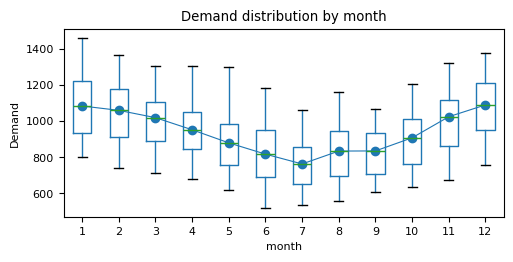

In [61]:
# Demand distribution by month
# ==============================================================================
fig, ax = plt.subplots(figsize=(5.5, 2.5))
data['month'] = data.index.month
data.boxplot(column='Demand', by='month', ax=ax,)
data.groupby('month')['Demand'].median().plot(style='o-', linewidth=0.8, ax=ax)
ax.set_ylabel('Demand')
ax.set_title('Demand distribution by month')
fig.suptitle('')
plt.show();

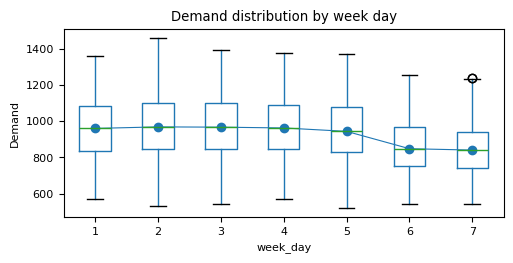

In [62]:
# Demand distribution by week day
# ==============================================================================
fig, ax = plt.subplots(figsize=(5.5, 2.5))
data['week_day'] = data.index.day_of_week + 1
data.boxplot(column='Demand', by='week_day', ax=ax)
data.groupby('week_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=ax)
ax.set_ylabel('Demand')
ax.set_title('Demand distribution by week day')
fig.suptitle('')
plt.show();

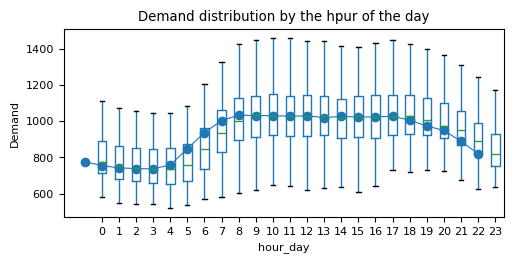

In [63]:
# Demand distribution by the hour of the day
# ==============================================================================
fig, ax = plt.subplots(figsize=(5.5, 2.5))
data['hour_day'] = data.index.hour 
data.boxplot(column='Demand', by='hour_day', ax=ax)
data.groupby('hour_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=ax)
ax.set_ylabel('Demand')
ax.set_title('Demand distribution by the hpur of the day')
fig.suptitle('')
plt.show();

## 🔁 Autocorrelation (ACF) — what & why

* **What it plots:** correlation of `Demand` with its **own past values** at lag 1, 2, …, up to `7*24` hours (one week).
* **How to read:**

  * **Tall spikes at 24, 48, …, 168** → strong **daily/weekly seasonality**.
  * **Slow decay** at small lags → short-memory AR structure.
  * Bars outside the **confidence band** are statistically significant.
* **Why useful:** guides **lag feature selection** (e.g., include 1–48, 24, 168) and helps spot seasonality/leakage before modeling.



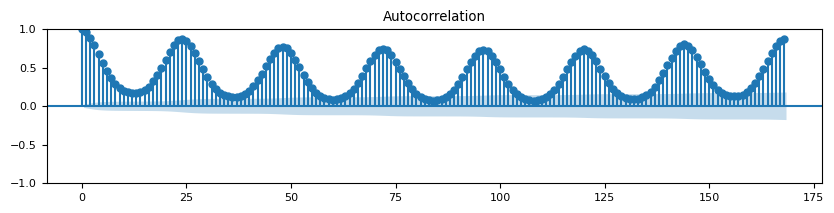

In [64]:
# Autocorrelation plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 2))
plot_acf(data.Demand, ax=ax, lags=7*24)
plt.show()


## ✂️ Partial Autocorrelation (PACF) — what & why

* **What it plots:** the **direct** correlation between `Demand_t` and `Demand_{t–k}` **after removing** the effect of intermediate lags (k−1, k−2, …).
* **How to read:**

  * A sharp cut-off after, say, lag **p** suggests an **AR(p)**-type dependence.
  * Significant spikes at **24** or **168** support adding **seasonal AR** terms or seasonal lag features.
* **Why useful:** helps set **AR order** (and seasonal AR order) or pick **minimal, non-redundant** lags for ML models.

> ⚠️ Tip: ACF/PACF are most interpretable on (quasi) **stationary** series. If you see very slow decay, consider detrending/differencing before AR/ARIMA diagnostics.


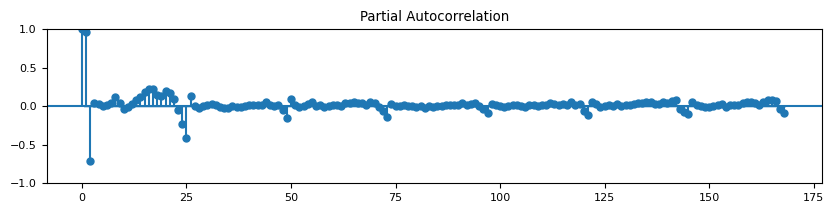

In [65]:
# Partial autocorrelation plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 2))
plot_pacf(data.Demand, ax=ax, lags=7*24)
plt.show()

## 🔍 Zoomed time-window view 

* **Does:** plots full `Demand` (top) and a **zoomed range** (`2022-11-07 → 2022-11-21`) below; blue band marks the zoom on the main chart.
* **Read:** top = **context**; bottom = **detail** (daily cycles, peaks, ramps).
* **Why useful:** quick anomaly checks, event inspection, and verifying preprocessing without losing the big picture.


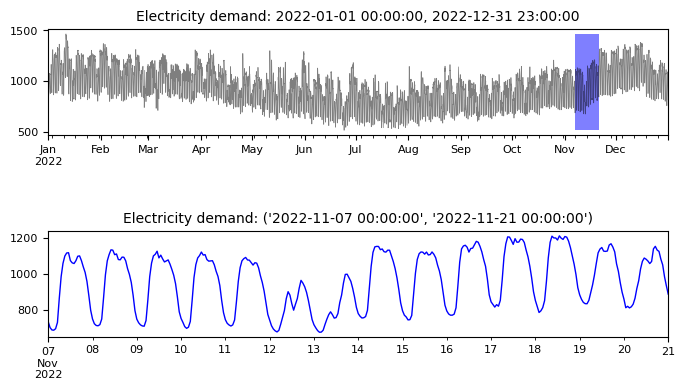

In [66]:
# Zooming time series chart
# ==============================================================================
zoom = ('2022-11-07 00:00:00', '2022-11-21 00:00:00')
fig = plt.figure(figsize=(8, 4))
grid = plt.GridSpec(nrows=8, ncols=1, hspace=0.6, wspace=0)
main_ax = fig.add_subplot(grid[:3, :])
data.Demand.plot(ax=main_ax, c='black', alpha=0.5, linewidth=0.5)
min_y = min(data.Demand)
max_y = max(data.Demand)
main_ax.fill_between(zoom, min_y, max_y, facecolor='blue', alpha=0.5, zorder=0)
main_ax.set_title(f'Electricity demand: {data.index.min()}, {data.index.max()}', fontsize=10)
main_ax.set_xlabel('')
zoom_ax = fig.add_subplot(grid[5:, :])
data.loc[zoom[0]: zoom[1]].Demand.plot(ax=zoom_ax, color='blue', linewidth=1)
zoom_ax.set_title(f'Electricity demand: {zoom}', fontsize=10)
zoom_ax.set_xlabel('')
plt.subplots_adjust(hspace=1)
plt.show();

# 🧭 Seasonal Naive Baseline 

* **What you build:** two simple references:

  * `lag_24_7` → **same hour, a week ago** (captures weekly pattern).
  * `lag_24` → **same hour, yesterday** (captures daily pattern).
* **How you evaluate:** pick a 24 h window (`2022-11-04`), plot **actual vs baseline** lines, and compute **MAPE** for each:

  * lower MAPE ⇒ baseline matches that day’s shape better.
* **Why useful:** sets a **performance floor**—your ML model should **beat both** daily and weekly seasonal naïve; if not, revisit features/splits.
* **Reading the plots:** check if the baseline **tracks peaks & valleys**; weekly often wins when weekday patterns dominate, daily helps when yesterday resembles today.


In [67]:
baseline = data[['Demand']].copy()
baseline['lag_24_7'] = baseline['Demand'].shift(24*7)
baseline['lag_24'] = baseline['Demand'].shift(24)

baseline.tail(24)

,Demand,lag_24_7,lag_24
timestamp,,,
2022-12-31 00:00:00,834.0,871.0,876.8
2022-12-31 01:00:00,787.6,839.6,840.8
2022-12-31 02:00:00,770.9,826.0,824.1
2022-12-31 03:00:00,758.8,812.1,807.8
2022-12-31 04:00:00,760.8,806.8,802.5
2022-12-31 05:00:00,766.6,815.3,820.9
2022-12-31 06:00:00,797.5,841.1,874.2
2022-12-31 07:00:00,834.3,878.2,942.2
2022-12-31 08:00:00,880.8,931.6,1018.6


MAPE: 1.552


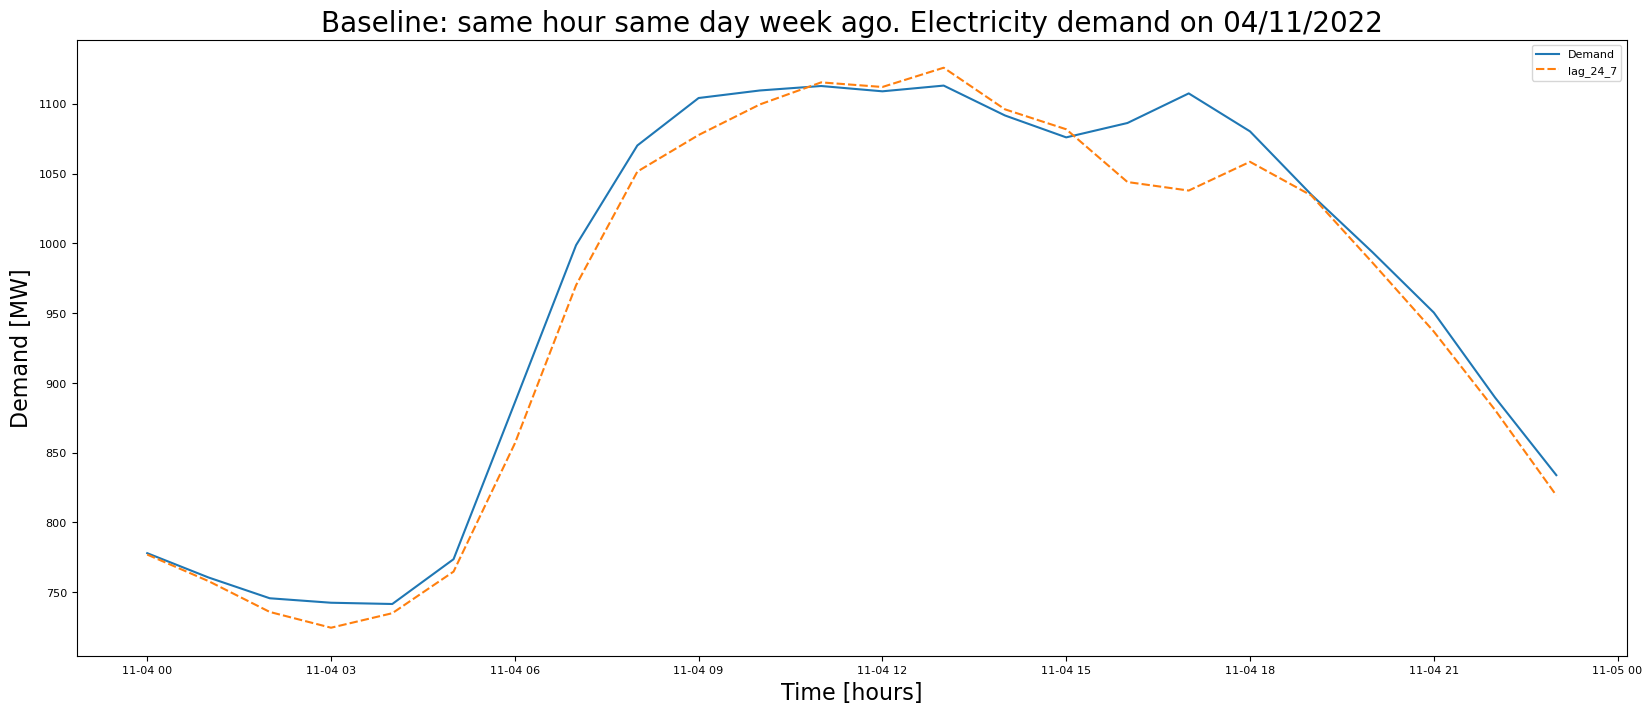

In [68]:
predict_for_start = datetime.datetime(2022,11,4)
predict_for_end = predict_for_start + datetime.timedelta(days = 1)

testing_vector = baseline[(baseline.index >= predict_for_start) &  (baseline.index < predict_for_end)]

plt.figure(figsize=(20,8))
plt.title(predict_for_start.date())
p = sns.lineplot(data = testing_vector[['Demand','lag_24_7']]);
plt.title("Baseline: same hour same day week ago. Electricity demand on 04/11/2022", fontsize = 20)
p.set_xlabel("Time [hours]", fontsize = 16);
p.set_ylabel("Demand [MW]", fontsize = 16);

print("MAPE: %.3f" % (mean_absolute_percentage_error(testing_vector['Demand'], testing_vector['lag_24_7'])*100))

MAPE: 0.894


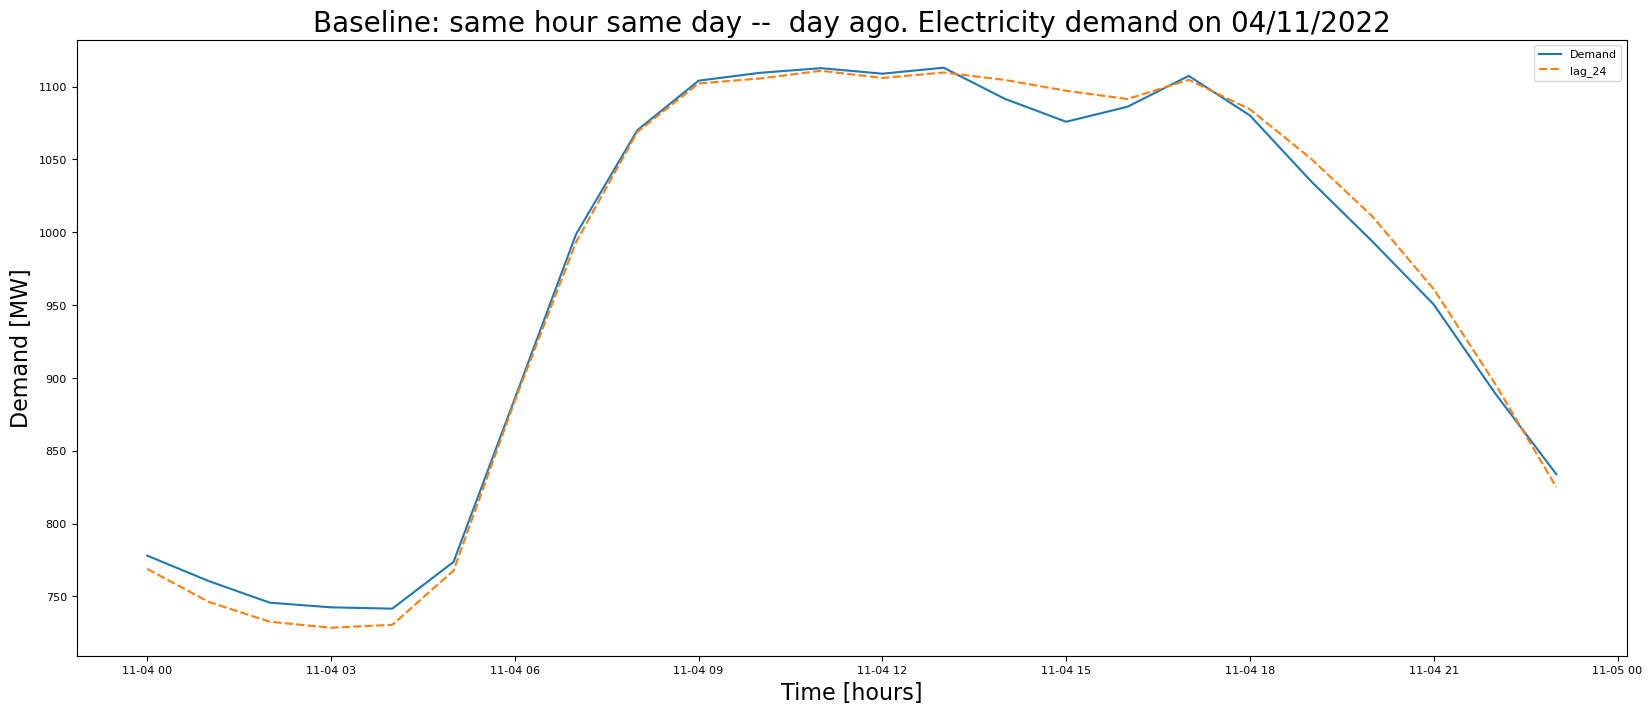

In [69]:
plt.figure(figsize=(20,8))
plt.title(predict_for_start.date())
p = sns.lineplot(data = testing_vector[['Demand','lag_24']]);
plt.title("Baseline: same hour same day --  day ago. Electricity demand on 04/11/2022", fontsize = 20)
p.set_xlabel("Time [hours]", fontsize = 16);
p.set_ylabel("Demand [MW]", fontsize = 16);

print("MAPE: %.3f" % (mean_absolute_percentage_error(testing_vector['Demand'], testing_vector['lag_24'])*100))

# 🔧 Linear regression on seasonal lags

**Idea:** learn a **weighted blend** of two seasonality proxies to predict each hour:

* `lag_24` (yesterday’s same hour) captures **daily** pattern.
* `lag_24_7` (same hour a week ago) captures **weekly** pattern.

Your **training window** is the **prior 30 days** (rolling), and you **test** on the **next 24 hours** (`2022-11-04`). This is a proper **time-ordered split** (no leakage):

$
\hat y_t ;=; \beta_0 ;+; \beta_1,y_{t-24} ;+; \beta_2,y_{t-168}
$

**Why this is a great step-up from naïve:**

* Instead of picking *only* yesterday *or* last week, the model **learns the best mixture** for the current regime (e.g., weekdays may lean more on weekly seasonality, holidays on daily).
* Coefficients $\beta_1,\beta_2$ adapt over time as you retrain on the latest month → **regional/seasonal drift** is handled better than fixed naïves.

**How to read results:**

* The plot (actual vs prediction) should **track peaks/valleys** more closely than either single-lag baseline.
* **MAPE** gives an immediate sense of improvement. If MAPE barely beats SNaïve, consider richer features.

**Assumptions & caveats:**

* Assumes a **linear** relationship between today and the two lags; strong **nonlinearities** (heat waves, holidays) may limit accuracy.
* `lag_24` and `lag_24_7` can be **correlated** → watch for multicollinearity (it mostly affects interpretability more than prediction here).
* Works best when **patterns are stable**; sudden structural changes (controls/DR events) can degrade performance.

**Quick upgrades (still lightweight):**

* Add **hour-of-day** and **weekday** dummies to capture deterministic seasonality.
* Add **weather** (temp, feels-like, humidity) and simple interactions (e.g., temp × hour).
* Try **regularization** (Ridge/Lasso) to stabilize coefficients when features grow.
* Use **rolling refits** (daily) and evaluate **per-horizon errors** (h=1…24) to catch late-day drift.

**Where this strategy fits:**

* A **strong baseline** between naïve and heavier ML (XGBoost/Random Forest, skforecast).
* Fast to train, easy to explain, and often surprisingly competitive for day-ahead shapes.


MAPE: 1.021


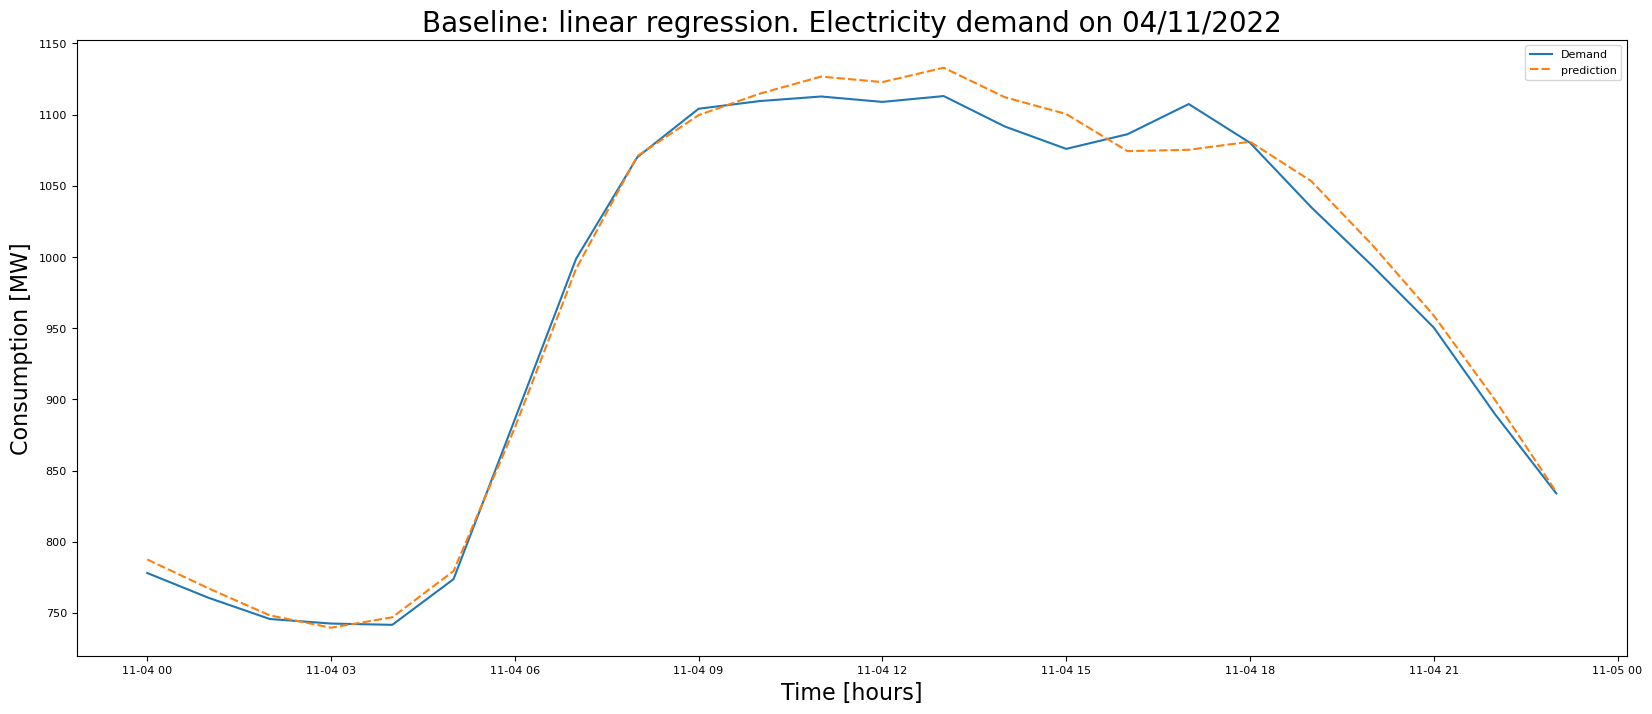

In [70]:
predict_for_start = datetime.datetime(2022,11,4)
predict_for_end = predict_for_start + datetime.timedelta(days = 1)

training_end = predict_for_start - datetime.timedelta(days = 1)
training_start = training_end - datetime.timedelta(days = 30)

testing_vector = baseline[(baseline.index >= predict_for_start) &  (baseline.index < predict_for_end)]
training_vector = baseline[(baseline.index >= training_start) &  (baseline.index < training_end)]

X_test = testing_vector[['lag_24', 'lag_24_7']]
y_test = testing_vector[['Demand']]

X_train = training_vector[['lag_24', 'lag_24_7']]
y_train = training_vector[['Demand']]

model = LinearRegression()
model.fit(X_train,y_train)

predictions_vector =  pd.DataFrame(model.predict(X_test))
predictions_vector.set_index(y_test.index, inplace=True)
predictions_vector = predictions_vector.rename(columns = {0:'prediction'})

plt.figure(figsize=(20,8))
plt.title(predict_for_start.date())
p = sns.lineplot(data = y_test.join(predictions_vector));
plt.title("Baseline: linear regression. Electricity demand on 04/11/2022", fontsize = 20)
p.set_xlabel("Time [hours]", fontsize = 16);
p.set_ylabel("Consumption [MW]", fontsize = 16);

print("MAPE: %.3f" % (mean_absolute_percentage_error(y_test, predictions_vector)*100))

# 🚀 Multi-step-ahead (Direct) forecast — per-horizon linear models

**What this does:**
You build a **Direct** multi-step forecaster by training a **separate model for each horizon** (h=0…23). For every hour-ahead:

1. **Slice the data for that horizon** with `hour_day == h` so each model only learns the mapping relevant to its specific step (e.g., *t+5*).
2. **Drop non-predictor columns** (`hour_day`, `Demand`) from `X_*`; keep only features (lags, calendar, weather, etc.).
3. **Fit a LinearRegression** on the last 30 days (`training_vector`) and **predict** on the target date (`testing_vector`).
4. **Append** the single prediction for that horizon into `predictions`, then convert to a DataFrame.

**Why this strategy:**

* ✅ **No error accumulation** (unlike recursive): each step is predicted directly from features.
* ✅ **Heterogeneity by horizon:** hour-ahead=1 can behave differently than hour-ahead=23; separate models capture that.
* ✅ **Fast and interpretable** with linear models; easy to extend to Ridge/Lasso.

**How to prepare features:**
Use robust **lags** (1–48, 24, 168), **calendar** (hour, weekday, holidays), and **weather**. Ensure features are aligned so they are **known at forecast time**.

**Reading results:**
The `predictions` vector now contains a **coherent 24-hour profile** for the day. Evaluate **per-horizon MAE/MAPE** (e.g., peaks vs nights often differ) and also an aggregated score.

**Caveats & upgrades:**

* Ensure `direct.hour_day` (or your horizon index) is correctly created beforehand.
* Guard against **small samples** per horizon; consider **regularization** (Ridge/Lasso) or tree models.
* For cleaner, production-ready code (and built-in backtesting), consider `ForecasterAutoregDirect` from skforecast; it automates this direct strategy while keeping your feature engineering.


![diagram-direct-multi-step-forecasting.png](assets/diagram-direct-multi-step-forecasting.png)


In [71]:
direct = data[['Demand','hour_day']].copy()
idx_positions = np.arange(len(direct))

for x in range(1,25):
    cname = "lag_" + str(x)
    shifted_idx_positions = idx_positions - (direct["hour_day"]+x)
    shifted_loc_index = direct.index[shifted_idx_positions]
    direct[cname] = direct.loc[shifted_loc_index, "Demand"].values

direct.tail(48)

,Demand,hour_day,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
timestamp,,,,,,,,,,,,,,,,,,,,,
2022-12-30 00:00:00,876.8,0,919.6,977.8,1031.4,1077.0,1105.1,1142.3,1167.5,1175.1,...,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3,850.6,885.9
2022-12-30 01:00:00,840.8,1,919.6,977.8,1031.4,1077.0,1105.1,1142.3,1167.5,1175.1,...,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3,850.6,885.9
2022-12-30 02:00:00,824.1,2,919.6,977.8,1031.4,1077.0,1105.1,1142.3,1167.5,1175.1,...,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3,850.6,885.9
2022-12-30 03:00:00,807.8,3,919.6,977.8,1031.4,1077.0,1105.1,1142.3,1167.5,1175.1,...,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3,850.6,885.9
2022-12-30 04:00:00,802.5,4,919.6,977.8,1031.4,1077.0,1105.1,1142.3,1167.5,1175.1,...,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3,850.6,885.9
2022-12-30 05:00:00,820.9,5,919.6,977.8,1031.4,1077.0,1105.1,1142.3,1167.5,1175.1,...,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3,850.6,885.9
2022-12-30 06:00:00,874.2,6,919.6,977.8,1031.4,1077.0,1105.1,1142.3,1167.5,1175.1,...,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3,850.6,885.9
2022-12-30 07:00:00,942.2,7,919.6,977.8,1031.4,1077.0,1105.1,1142.3,1167.5,1175.1,...,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3,850.6,885.9
2022-12-30 08:00:00,1018.6,8,919.6,977.8,1031.4,1077.0,1105.1,1142.3,1167.5,1175.1,...,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3,850.6,885.9


In [72]:
direct.loc[direct.hour_day==0]

,Demand,hour_day,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
timestamp,,,,,,,,,,,,,,,,,,,,,
2022-01-01,899.4,0,817.6,846.5,889.5,932.5,989.4,1042.8,1085.3,1091.7,...,922.4,880.8,834.3,797.5,766.6,760.8,758.8,770.9,787.6,834.0
2022-01-02,936.6,0,967.6,997.3,1030.9,1052.8,1064.3,1076.5,1069.1,1052.0,...,882.0,874.8,868.4,852.2,844.7,842.7,860.1,874.3,892.1,899.4
2022-01-03,923.0,0,964.9,1020.5,1073.9,1116.1,1140.5,1159.6,1164.5,1158.9,...,1013.3,983.2,933.6,900.3,878.2,883.9,891.8,899.7,917.2,936.6
2022-01-04,929.3,0,985.8,1068.0,1139.7,1196.0,1227.4,1262.2,1280.7,1309.2,...,1263.7,1227.8,1119.5,1010.0,909.4,902.0,886.2,905.1,923.7,923.0
2022-01-05,923.6,0,973.9,1046.7,1121.4,1167.9,1211.1,1242.4,1260.7,1266.4,...,1204.8,1183.4,1075.3,978.0,893.4,869.5,865.0,884.8,910.3,929.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-27,924.8,0,965.5,1013.4,1064.2,1100.6,1124.6,1144.7,1159.3,1154.8,...,1039.8,995.9,944.0,900.7,859.1,833.0,825.7,836.9,851.5,871.5
2022-12-28,872.7,0,902.2,973.0,1033.4,1084.0,1113.8,1143.2,1169.8,1182.3,...,1184.4,1155.1,1065.1,981.7,913.5,887.3,886.8,890.7,907.1,924.8
2022-12-29,885.9,0,927.6,981.4,1045.1,1095.1,1124.6,1164.6,1168.5,1179.6,...,1110.8,1078.1,987.4,905.8,844.5,825.3,824.7,830.9,848.3,872.7


In [73]:
predict_for_start = datetime.datetime(2022,11,4)
predict_for_end = predict_for_start + datetime.timedelta(days = 1)

training_end = predict_for_start - datetime.timedelta(days = 1)
training_start = training_end - datetime.timedelta(days = 30)

testing_vector = direct[(direct.index >= predict_for_start) &  (direct.index < predict_for_end)]
training_vector = direct[(direct.index >= training_start) &  (direct.index < training_end)]

In [74]:
X_test = testing_vector.loc[direct.hour_day==0]
X_test = X_test .loc[:, ~X_test.columns.isin(['hour_day', 'Demand'])]

y_test = testing_vector[['Demand']].loc[direct.hour_day==0]

X_train = training_vector.loc[direct.hour_day==0]
X_train = X_train .loc[:, ~X_train .columns.isin(['hour_day', 'Demand'])]

y_train = training_vector[['Demand']].loc[direct.hour_day==0]

X_train

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
timestamp,,,,,,,,,,,,,,,,,,,,,
2022-10-04,792.1,878.0,950.3,1001.7,1026.0,1007.7,1024.5,1042.5,1032.7,1038.5,...,1065.0,1021.8,945.6,832.9,711.3,682.7,682.5,692.2,708.8,724.0
2022-10-05,789.6,869.4,937.6,990.2,1024.1,1003.5,1004.5,1011.4,1029.5,1043.8,...,1082.2,1052.3,974.9,859.2,739.9,708.7,711.1,716.2,728.5,747.7
2022-10-06,768.6,854.6,931.2,978.0,1008.2,1003.6,1015.0,1035.3,1067.3,1080.7,...,1093.0,1055.0,975.4,867.2,760.0,727.6,720.3,724.1,734.5,745.8
2022-10-07,773.8,850.9,927.6,970.8,991.5,964.9,986.9,992.9,1006.9,1093.2,...,1069.8,1021.1,941.0,822.0,718.2,692.6,692.5,689.9,701.3,724.4
2022-10-08,759.2,827.5,885.5,928.4,960.1,946.0,947.9,935.4,926.0,910.0,...,1032.1,991.9,928.2,828.6,719.1,693.0,689.8,695.9,706.7,732.3
2022-10-09,743.8,797.5,852.0,885.0,915.4,888.5,899.2,892.7,842.6,790.5,...,783.2,766.1,733.8,711.2,678.5,674.6,679.7,686.2,705.6,722.9
2022-10-10,749.4,810.4,865.3,910.2,939.3,883.8,838.8,769.2,712.9,690.2,...,784.9,749.1,713.0,691.5,663.1,660.2,662.2,669.5,676.3,703.1
2022-10-11,766.4,841.0,910.1,956.6,985.4,958.6,951.4,943.6,934.0,912.8,...,1030.4,993.3,926.4,827.9,716.5,683.3,676.3,684.2,695.6,715.1
2022-10-12,782.6,863.7,931.5,982.9,1007.7,984.4,974.6,984.9,1025.7,1097.9,...,1006.3,994.7,947.6,842.1,733.5,700.4,694.1,698.4,707.0,726.5


In [75]:
model = LinearRegression()
model.fit(X_train,y_train)

prediction =  pd.DataFrame(model.predict(X_test))
prediction[0][0]

787.2628559563381

In [76]:
predictions = np.array([]) 
for h in range(24):
    X_test = testing_vector.loc[direct.hour_day==h]
    X_test = X_test .loc[:, ~X_test.columns.isin(['hour_day', 'Demand'])]

    y_test = testing_vector[['Demand']].loc[direct.hour_day==h]

    X_train = training_vector.loc[direct.hour_day==h]
    X_train = X_train.loc[:, ~X_train .columns.isin(['hour_day', 'Demand'])]

    y_train = training_vector[['Demand']].loc[direct.hour_day==h]
    
    model = LinearRegression()
    model.fit(X_train,y_train)

    prediction =  pd.DataFrame(model.predict(X_test))
    predictions = np.append(predictions, np.array([prediction[0][0]])) 

predictions =  pd.DataFrame(predictions)


MAPE: 3.843


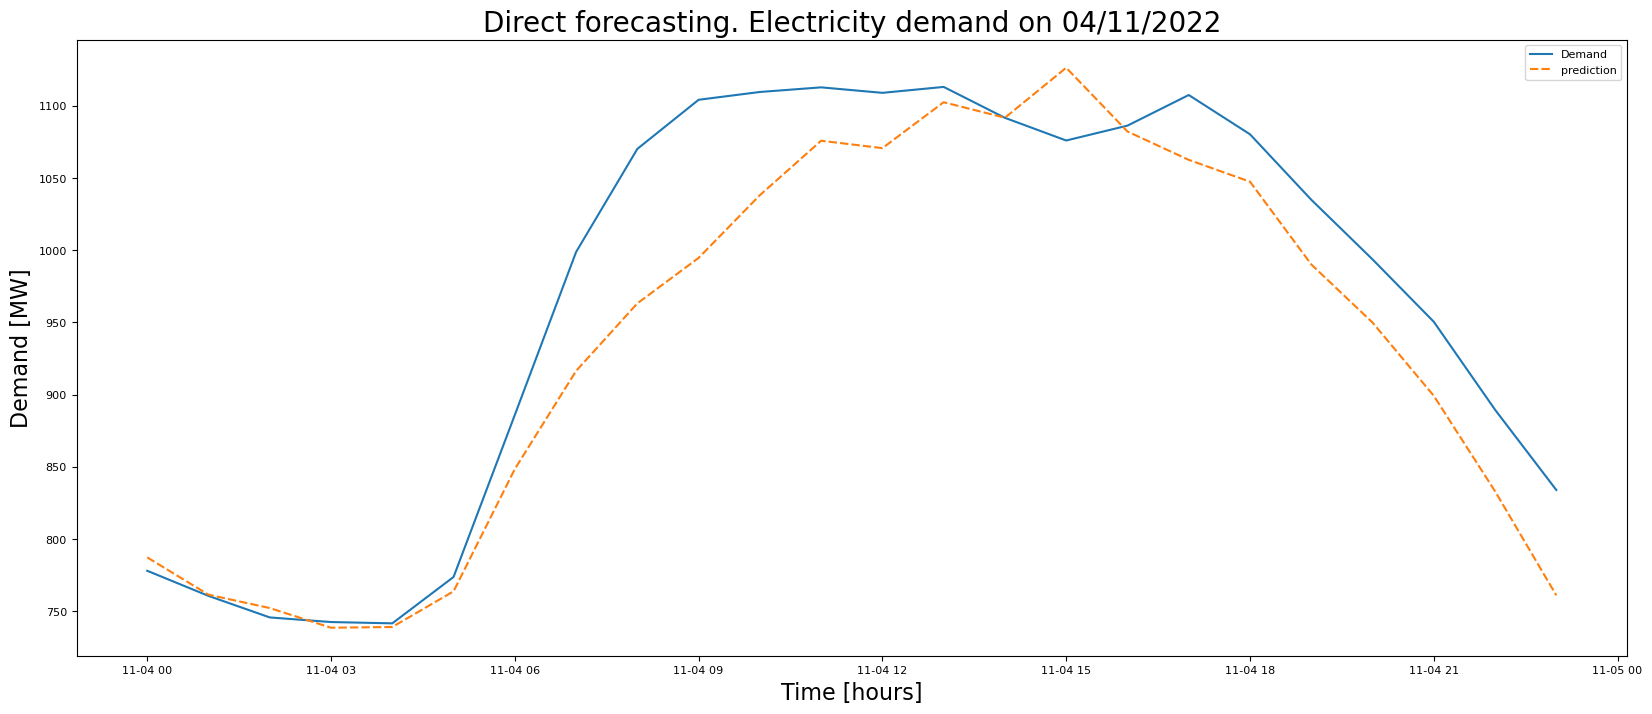

In [77]:
y_test = testing_vector[['Demand']]
y_test
predictions.set_index(y_test.index, inplace=True)
predictions = predictions.rename(columns = {0:'prediction'})

plt.figure(figsize=(20,8))
plt.title(predict_for_start.date())
p = sns.lineplot(data = y_test.join(predictions));
plt.title("Direct forecasting. Electricity demand on 04/11/2022", fontsize = 20)
p.set_xlabel("Time [hours]", fontsize = 16);
p.set_ylabel("Demand [MW]", fontsize = 16);

print("MAPE: %.3f" % (mean_absolute_percentage_error(y_test, predictions)*100))

# 🔁 Multi-step Forecast — Recursive
**🌱 Idea:** train **one** next-step model and then **roll it forward** 👉 each new prediction becomes the **latest lag** for the following step. Think AR-style forecasting but with your engineered features.

**🧩 How it works (conceptually):**

1. **Fit once** on recent history to predict **t+1** from current lags/features.
2. **Forecast the first hour** of the target day (seed).
3. **Shift the feature window** by 1 hour and **inject** the forecast as the newest lag (e.g., `lag_1 ← ŷ`).
4. **Repeat** for hours 2…24 to build the full day-ahead vector.

**📊 Evaluation:**

* Compare the 24 predicted points to actuals on that day; report **MAPE/MAE/RMSE**.
* Plot **actual vs predicted** to check if peaks/valleys are tracked and how errors **grow with horizon**.

**✅ When it shines:**

* **Short horizons** or **frequent retraining**.
* Strong **short-term autocorrelation** (yesterday’s recent hours are informative).
* You need something **fast and simple** as a baseline.

**⚠️ Watch out for:**

* **Error accumulation:** early mistakes propagate to later hours.
* **Consistent lag shifting:** all lags (1, 2, 24, 168, …) must advance together each step.
* **Feature mismatch:** ensure test features use **exactly** the same columns and order as training.

**💡 Easy upgrades:**

* Add **regularization** (Ridge/Lasso) for stability.
* Maintain a tiny **history buffer** to update many lags cleanly each step.
* Benchmark against **Direct** (per-horizon models) to see if removing feedback improves long-horizon stability.
* Include **calendar/weather features** so the model isn’t driven by lags alone.

 
Recursive multi-step = **one model, rolled forward**. It’s fast and often strong up close—but check for **drift** as the horizon grows.


![diagram-recursive-mutistep-forecasting.png](assets/diagram-recursive-mutistep-forecasting.png)

In [78]:
recursive = data[['Demand','hour_day']].copy()
for x in range(1,25):
    cname = "lag_" + str(x)
    recursive[cname] = recursive['Demand'].shift(x)
recursive.tail(48)

,Demand,hour_day,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
timestamp,,,,,,,,,,,,,,,,,,,,,
2022-12-30 00:00:00,876.8,0,919.6,977.8,1031.4,1077.0,1105.1,1142.3,1167.5,1175.1,...,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3,850.6,885.9
2022-12-30 01:00:00,840.8,1,876.8,919.6,977.8,1031.4,1077.0,1105.1,1142.3,1167.5,...,1130.2,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3,850.6
2022-12-30 02:00:00,824.1,2,840.8,876.8,919.6,977.8,1031.4,1077.0,1105.1,1142.3,...,1142.0,1130.2,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8,827.3
2022-12-30 03:00:00,807.8,3,824.1,840.8,876.8,919.6,977.8,1031.4,1077.0,1105.1,...,1138.7,1142.0,1130.2,1113.0,1080.3,995.0,924.7,870.7,821.5,819.8
2022-12-30 04:00:00,802.5,4,807.8,824.1,840.8,876.8,919.6,977.8,1031.4,1077.0,...,1139.2,1138.7,1142.0,1130.2,1113.0,1080.3,995.0,924.7,870.7,821.5
2022-12-30 05:00:00,820.9,5,802.5,807.8,824.1,840.8,876.8,919.6,977.8,1031.4,...,1134.8,1139.2,1138.7,1142.0,1130.2,1113.0,1080.3,995.0,924.7,870.7
2022-12-30 06:00:00,874.2,6,820.9,802.5,807.8,824.1,840.8,876.8,919.6,977.8,...,1151.2,1134.8,1139.2,1138.7,1142.0,1130.2,1113.0,1080.3,995.0,924.7
2022-12-30 07:00:00,942.2,7,874.2,820.9,802.5,807.8,824.1,840.8,876.8,919.6,...,1175.1,1151.2,1134.8,1139.2,1138.7,1142.0,1130.2,1113.0,1080.3,995.0
2022-12-30 08:00:00,1018.6,8,942.2,874.2,820.9,802.5,807.8,824.1,840.8,876.8,...,1167.5,1175.1,1151.2,1134.8,1139.2,1138.7,1142.0,1130.2,1113.0,1080.3


In [79]:
predict_for_start = datetime.datetime(2022,11,4)
predict_for_end = predict_for_start + datetime.timedelta(days = 1)

training_end = predict_for_start - datetime.timedelta(days = 1)
training_start = training_end - datetime.timedelta(days = 30)

testing_vector = recursive[(recursive.index >= predict_for_start) &  (recursive.index < predict_for_end)]
training_vector = recursive[(recursive.index >= training_start) &  (recursive.index < training_end)]

In [80]:
X_train = training_vector.loc[:, ~training_vector .columns.isin(['hour_day', 'Demand'])]
y_train = training_vector[['Demand']]
X_train

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
timestamp,,,,,,,,,,,,,,,,,,,,,
2022-10-04 00:00:00,792.1,878.0,950.3,1001.7,1026.0,1007.7,1024.5,1042.5,1032.7,1038.5,...,1065.0,1021.8,945.6,832.9,711.3,682.7,682.5,692.2,708.8,724.0
2022-10-04 01:00:00,747.7,792.1,878.0,950.3,1001.7,1026.0,1007.7,1024.5,1042.5,1032.7,...,1069.5,1065.0,1021.8,945.6,832.9,711.3,682.7,682.5,692.2,708.8
2022-10-04 02:00:00,728.5,747.7,792.1,878.0,950.3,1001.7,1026.0,1007.7,1024.5,1042.5,...,1068.1,1069.5,1065.0,1021.8,945.6,832.9,711.3,682.7,682.5,692.2
2022-10-04 03:00:00,716.2,728.5,747.7,792.1,878.0,950.3,1001.7,1026.0,1007.7,1024.5,...,1064.0,1068.1,1069.5,1065.0,1021.8,945.6,832.9,711.3,682.7,682.5
2022-10-04 04:00:00,711.1,716.2,728.5,747.7,792.1,878.0,950.3,1001.7,1026.0,1007.7,...,1048.5,1064.0,1068.1,1069.5,1065.0,1021.8,945.6,832.9,711.3,682.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-02 19:00:00,1065.7,1086.8,1081.1,1095.2,1091.0,1115.5,1101.1,1119.3,1113.2,1105.3,...,730.4,729.8,734.7,738.0,766.4,807.0,875.5,944.3,992.1,1025.2
2022-11-02 20:00:00,1036.6,1065.7,1086.8,1081.1,1095.2,1091.0,1115.5,1101.1,1119.3,1113.2,...,766.0,730.4,729.8,734.7,738.0,766.4,807.0,875.5,944.3,992.1
2022-11-02 21:00:00,999.1,1036.6,1065.7,1086.8,1081.1,1095.2,1091.0,1115.5,1101.1,1119.3,...,884.8,766.0,730.4,729.8,734.7,738.0,766.4,807.0,875.5,944.3


In [81]:
model = LinearRegression()
model.fit(X_train,y_train)

y_test = testing_vector[['Demand']]

X_test = testing_vector.loc[testing_vector.hour_day == 0]
X_test = X_test.loc[:, ~training_vector .columns.isin(['hour_day', 'Demand'])]

predictions = np.array([]) 

prediction =  pd.DataFrame(model.predict(X_test))
predictions = np.append(predictions, np.array([prediction[0][0]])) 

for h in range(1,24):
    prediction =  pd.DataFrame(model.predict(X_test))
    predictions = np.append(predictions, np.array([prediction[0][0]]))
    
    X_test = X_test.T.shift(1).copy()
    X_test = X_test.T
    X_test['lag_1'] = prediction[0][0]


MAPE: 3.939


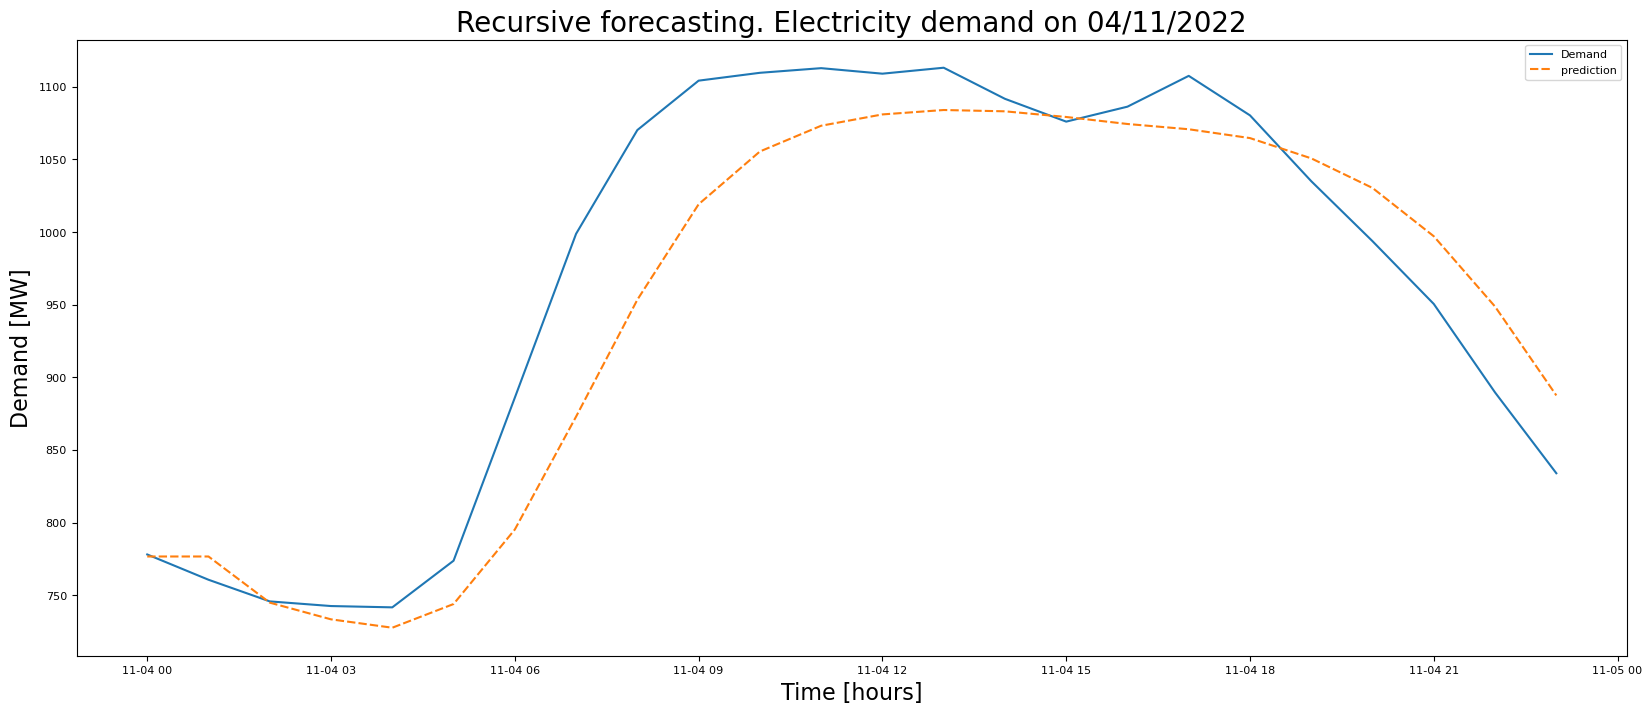

In [82]:
y_test = testing_vector[['Demand']]
y_test
predictions =  pd.DataFrame(predictions)

predictions.set_index(y_test.index, inplace=True)
predictions = predictions.rename(columns = {0:'prediction'})

plt.figure(figsize=(20,8))
plt.title(predict_for_start.date())
p = sns.lineplot(data = y_test.join(predictions));
plt.title("Recursive forecasting. Electricity demand on 04/11/2022", fontsize = 20)
p.set_xlabel("Time [hours]", fontsize = 16);
p.set_ylabel("Demand [MW]", fontsize = 16);

print("MAPE: %.3f" % (mean_absolute_percentage_error(y_test, predictions)*100))


# 🧪 Train–Val–Test split (time-aware)

* **What you’re doing:** carving the series into **three chronological blocks**:

  * **History (`data_train`)**: model learns patterns here (lags, seasonality).
  * **Validation (`data_val`)**: tune features/hyperparams and compare strategies.
  * **Test (`data_test`)**: **final, untouched** day for honest evaluation.

* **Why this matters:** time series must be split **forward in time** (no shuffling) to avoid **look-ahead leakage**. Each later block uses only information available up to its start.

* **Your ranges:**

  * `start_train → end_train` → **History**
  * `end_train → end_validation` → **Validation**
  * `end_validation → end_test` → **Test (target day)**
    The Plotly chart layers these as **History / Train / Test** so you can visually confirm boundaries and seasonality.

* **Tiny tips:**

  * Use timestamps that match your index granularity (e.g., `HH:00:00`).
  * Check that there’s **no overlap** between blocks (with hourly data, `...23:59:00` won’t match, so you’re safe).
  * For robust model choice, try **rolling/expanding** validation windows—not just a single split.


History      : 2022-09-01 00:00:00 --- 2022-10-02 23:00:00  (n=768)
Training dates : 2022-10-03 00:00:00 --- 2022-11-03 23:00:00  (n=768)
Test dates       : 2022-11-04 00:00:00 --- 2022-11-04 23:00:00  (n=24)


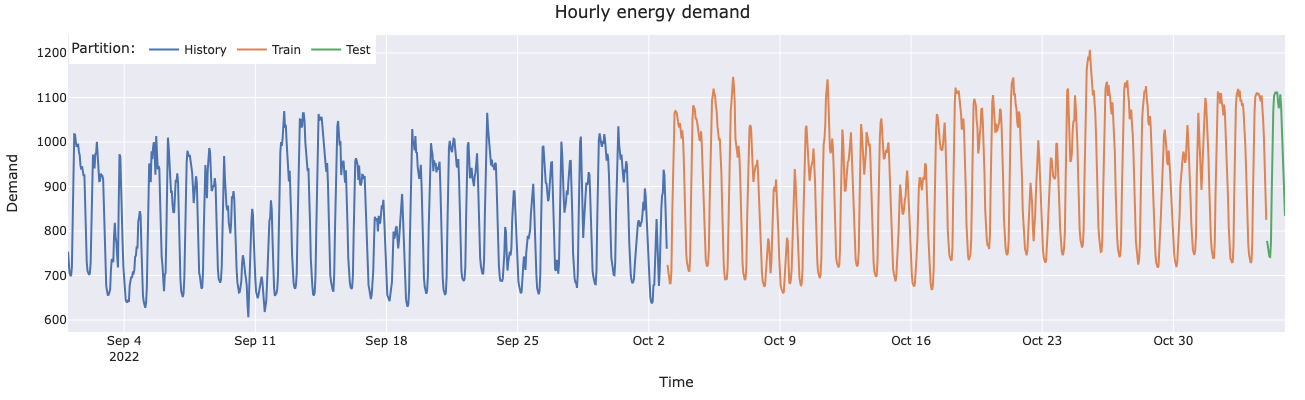

In [85]:
# Split data into train-val-test
# ==============================================================================
#data = data.loc['2022-01-01 00:00:00': '2022-12-31 23:00:00'].copy()
start_train = '2022-09-01 00:00:00'
end_train = '2022-10-02 23:59:00'
end_validation = '2022-11-03 23:59:00'
end_test = '2022-11-04 23:59:00'

data_train = data.loc[start_train: end_train, :].copy()
data_val   = data.loc[end_train:end_validation, :].copy()
data_test  = data.loc[end_validation:end_test, :].copy()

print(f"History      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Training dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

# Interactive plot of time series
# ==============================================================================
fig = go.Figure()
fig.add_trace(go.Scatter(x=data_train.index, y=data_train['Demand'], mode='lines', name='History'))
fig.add_trace(go.Scatter(x=data_val.index, y=data_val['Demand'], mode='lines', name='Train'))
fig.add_trace(go.Scatter(x=data_test.index, y=data_test['Demand'], mode='lines', name='Test'))
fig.update_layout(
    title  = 'Hourly energy demand',
    xaxis_title="Time",
    yaxis_title="Demand",
    legend_title="Partition:",
    width=750,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=1,
        xanchor="left",
        x=0.001
    )
)
#fig.update_xaxes(rangeslider_visible=True)
fig.show()

# 🧱 Temporal Cross-Validation (sliding & expanding) — why and how

* **Why:** time series models must be validated on **future blocks** to mimic deployment. Temporal CV gives multiple “train → validate” rounds, reducing luck from any single split and revealing **horizon-wise stability**.

* **Sliding window** 🚂

  * **Train span:** fixed length (e.g., last 60 days).
  * **Validation block:** fixed (e.g., next 7 days).
  * **Move forward** both windows by the validation size and repeat.
  * **Pros:** constant “model memory,” good for **local stationarity**.
  * **Cons:** throws away older data (may miss slow seasonal drift).

* **Expanding window** 🌱➡️🌳

  * **Train span:** grows over folds (accumulates all past).
  * **Validation block:** fixed (e.g., 7 days).
  * **Pros:** uses **all history**, better for **slow trends/seasonality**.
  * **Cons:** training cost grows; may overweight stale regimes.

* **Clean hold-out block** 🔒

  * Keep a **final untouched period** (e.g., last **2–4 weeks**) for the **endgame metric** after CV tuning.
  * Prevents subtle leakage from repeated model selection.

* **Practical tips** 🛠️

  * Use a **gap** (e.g., 24–48h) between train and validation folds when you create lag or rolling features to avoid leakage.
  * Evaluate **per-horizon metrics** (MAE/MAPE for h=1…24) *and* aggregated scores.
  * Track **variance across folds**—prefer models that are a bit better on average and **more stable**.
  * Log **runtime** and **retrain frequency**; the best CV score isn’t useful if it’s operationally impractical.
